In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\akash\Downloads\Data_science_project\food_wastage_cleaned.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Type of Food           1723 non-null   object 
 1   Number of Guests       1723 non-null   float64
 2   Event Type             1723 non-null   object 
 3   Quantity of Food       1723 non-null   float64
 4   Storage Conditions     1723 non-null   object 
 5   Purchase History       1723 non-null   object 
 6   Seasonality            1723 non-null   object 
 7   Preparation Method     1723 non-null   object 
 8   Geographical Location  1723 non-null   object 
 9   Pricing                1723 non-null   object 
 10  Wastage Food Amount    1723 non-null   float64
dtypes: float64(3), object(8)
memory usage: 148.2+ KB


In [4]:
df.describe()

,Number of Guests,Quantity of Food,Wastage Food Amount
count,1723.000000,1723.000000,1723.000000
mean,323.297737,418.485200,28.264074
std,79.508750,96.611548,10.225019
min,207.000000,280.000000,10.000000
25%,280.000000,350.000000,20.000000
50%,310.000000,400.000000,25.000000
75%,350.000000,480.000000,35.000000
max,765.000000,1130.000000,63.000000


In [5]:
df.nunique()

Type of Food              5
Number of Guests         40
Event Type                4
Quantity of Food         31
Storage Conditions        2
Purchase History          2
Seasonality               3
Preparation Method        3
Geographical Location     3
Pricing                   3
Wastage Food Amount      26
dtype: int64

## Target Variable Analysis
## What is the distribution of food waste?

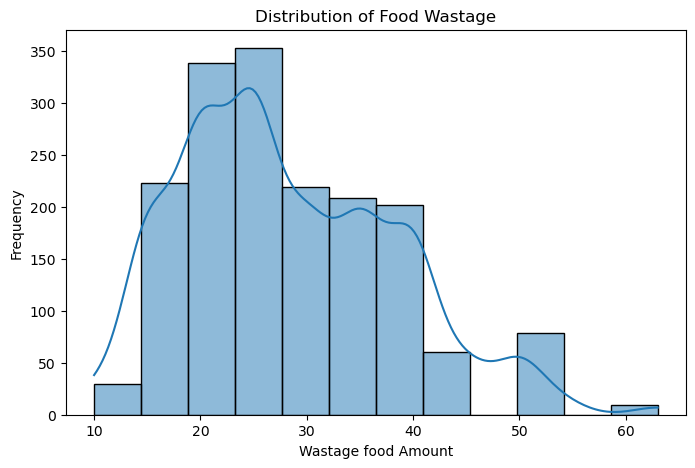

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df, x = "Wastage Food Amount" , kde = True, bins = 12)
plt.title("Distribution of Food Wastage")
plt.xlabel("Wastage food Amount")
plt.ylabel("Frequency")

plt.show()

### Observation:
The graph shows that most restaurant events generate a moderate amount of food wastage, mainly between **20 and 40 units**. A few events produce comparatively higher food wastage, but such cases are less frequent. This indicates that extreme food wastage is uncommon, while moderate wastage is more consistently observed across events.

## Checking Outliers:
## By checking numerical variables' distribution?

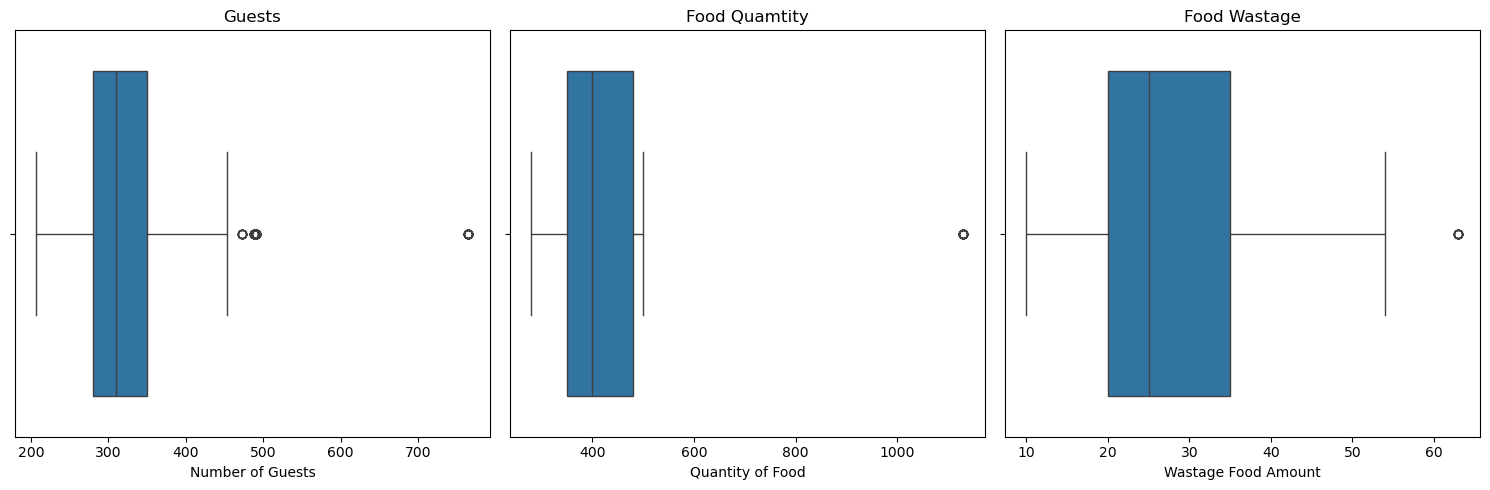

In [28]:
fig, axes = plt.subplots(1,3, figsize = (15,5))
sns.boxplot(x=df["Number of Guests"], ax= axes[0])
axes[0].set_title("Guests")
sns.boxplot(x=df["Quantity of Food"], ax= axes[1])
axes[1].set_title("Food Quamtity")
sns.boxplot(x=df["Wastage Food Amount"], ax= axes[2])
axes[2].set_title("Food Wastage")
plt.tight_layout()
plt.show()

### Observation:

The boxplots indicate the presence of a few outliers in the numerical variables, including **Number of Guests**, **Quantity of Food**, and **Wastage Food Amount**. However, these values appear to represent realistic restaurant scenarios, such as large events or higher food preparation, rather than data entry errors. Therefore, the outliers were retained for further analysis.

# Category vs Food Wastage Analysis:
## 1. Event Type vs Food Wastage

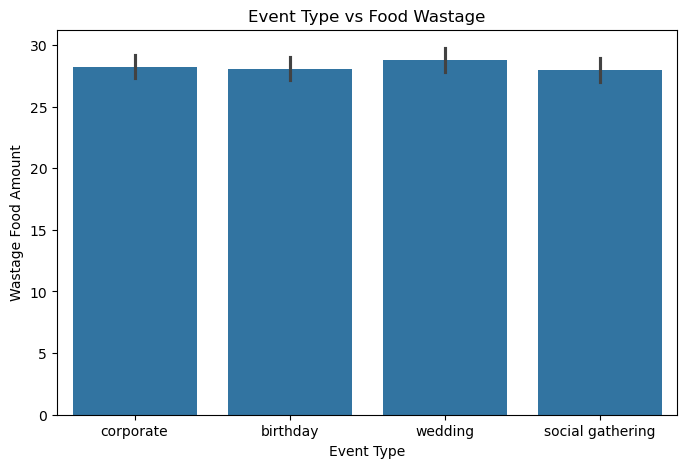

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x = df["Event Type"], y = df["Wastage Food Amount"])
plt.title("Event Type vs Food Wastage")
plt.show()

### Observation

The graph shows that the average food wastage across different event types is relatively similar, with only minor differences observed. Wedding events appear to generate slightly higher food wastage compared to other event types, while birthday and social gatherings show slightly lower wastage. Overall, event type alone does not appear to have a major impact on food wastage.

## 2. Type of Food vs Food Wastage

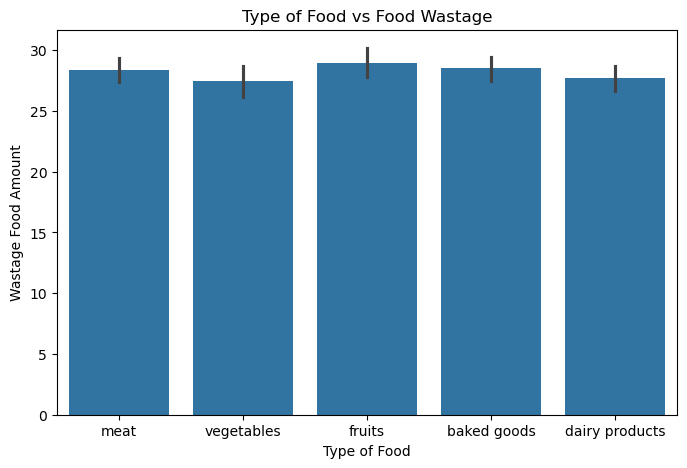

In [34]:
plt.figure(figsize = (8,5))
sns.barplot(x = df["Type of Food"], y  = df["Wastage Food Amount"])
plt.title("Type of Food vs Food Wastage")
plt.show()

### Observation

The graph indicates that the average food wastage across different food types is relatively similar, with only small variations observed. Fruits appear to generate slightly higher food wastage compared to other food categories, while vegetables and dairy products show comparatively lower wastage. Overall, the type of food does not appear to create a major difference in food wastage levels.

## 3. Storage Conditions vs Food Wastage

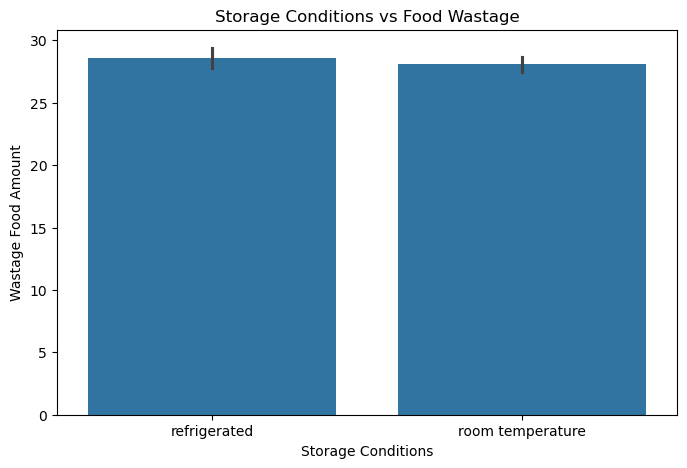

In [37]:
plt.figure(figsize = (8,5))
sns.barplot(x=df["Storage Conditions"], y = df["Wastage Food Amount"])
plt.title("Storage Conditions vs Food Wastage")
plt.show()

### Observation

The graph shows that average food wastage under refrigerated and room temperature storage conditions is relatively similar, with only minor differences observed. This suggests that storage condition alone may not have a strong impact on food wastage levels in this dataset.

## 4. Seasonality vs Food Wastage

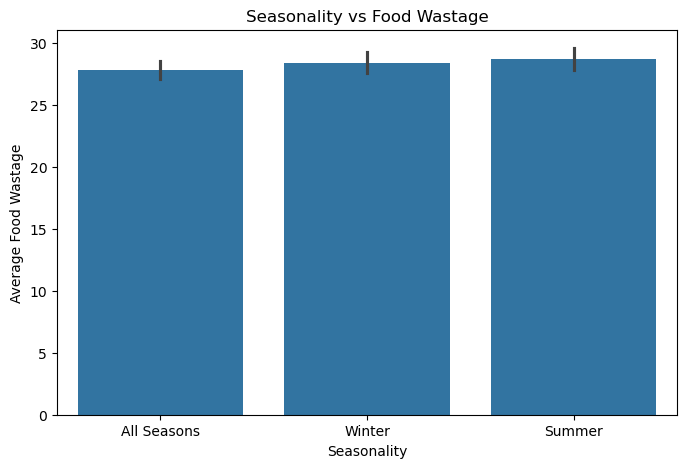

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Seasonality',
    y='Wastage Food Amount',
    data=df
)

plt.title("Seasonality vs Food Wastage")

plt.xlabel("Seasonality")
plt.ylabel("Average Food Wastage")

plt.show()

### Observation

The graph shows that average food wastage across different seasons is relatively similar, with only small variations observed. Summer appears to have slightly higher food wastage compared to winter and all-season events. However, the differences are minimal, suggesting that seasonality may not have a major influence on food wastage in this dataset.

# Numerical Relationship Analysis

## Number of Guests vs Food Wastage

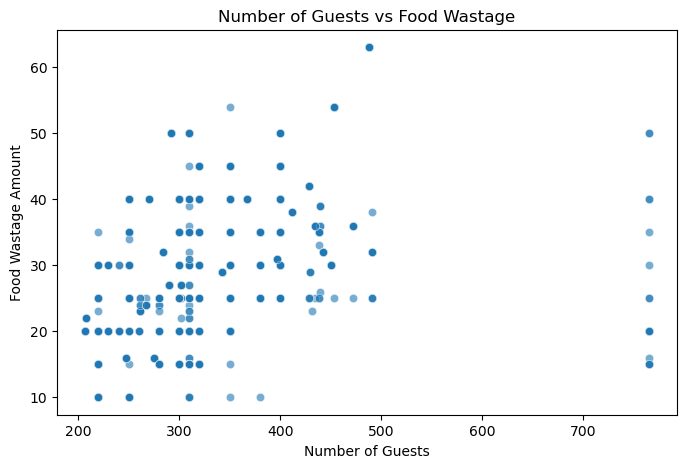

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Number of Guests',
    y='Wastage Food Amount',
    data=df, alpha = 0.6
)

plt.title("Number of Guests vs Food Wastage")

plt.xlabel("Number of Guests")
plt.ylabel("Food Wastage Amount")

plt.show()

### Observation

The scatterplot suggests a slight positive relationship between the number of guests and food wastage. As the number of guests increases, food wastage tends to increase as well. However, the points are moderately scattered, indicating that the number of guests alone may not fully determine food wastage, and other factors may also contribute.

## Quantity of Food vs Food Wastage

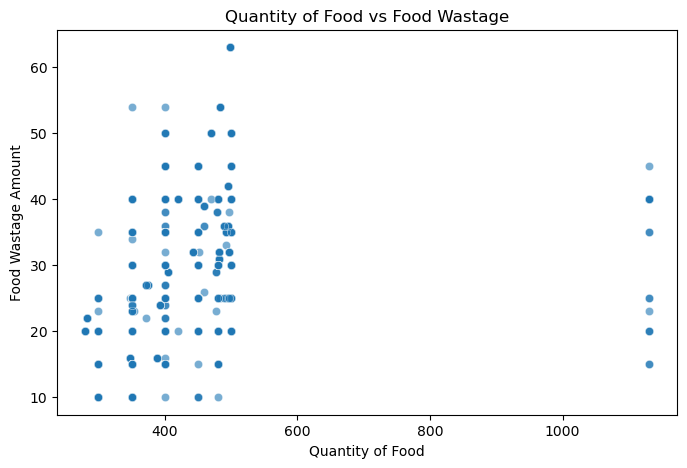

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Quantity of Food',
    y='Wastage Food Amount',
    data=df,
    alpha=0.6
)

plt.title("Quantity of Food vs Food Wastage")

plt.xlabel("Quantity of Food")
plt.ylabel("Food Wastage Amount")

plt.show()

### Observation

The scatterplot indicates a moderate positive relationship between the quantity of food prepared and food wastage. As the quantity of food increases, food wastage generally tends to increase as well. However, some variation is observed at similar food quantities, suggesting that food quantity alone may not completely determine wastage and that other factors may also influence it.

## Correlation Analysis

## Correlation values meaning
***Positive correlation (+)***   Example:0.47         
Means:As one increases, other tends to increase.

**Negative correlation (-)**     Example: -0.66        
Means:As one increases, other decreases.

**Near 0**           Example:0.02, -0.01   
Means:Almost no relationship.

In [42]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.select_dtypes(
    include='object'
).columns:
    
    df_encoded[col] = le.fit_transform(
        df_encoded[col]
    )

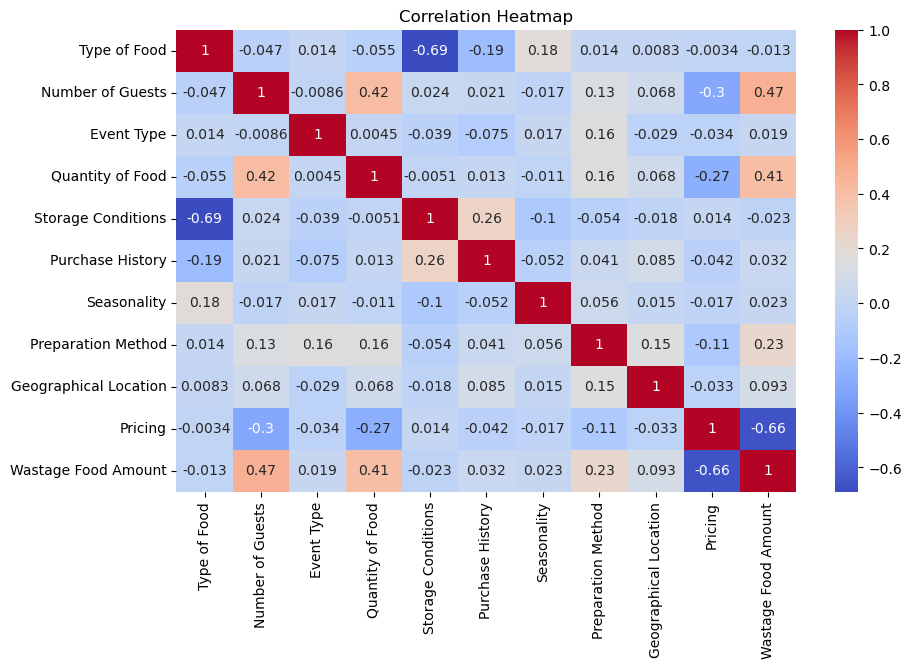

In [43]:
#Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows that **Number of Guests (0.47)** and **Quantity of Food (0.41)** have a moderate positive relationship with food wastage, indicating that larger gatherings and higher food preparation tend to increase wastage. **Pricing (-0.66)** shows a strong negative correlation with food wastage, suggesting that higher-priced food items may lead to lower wastage. Most categorical variables, including event type, seasonality, and storage conditions, exhibit very weak correlations, indicating a limited influence on food wastage in this dataset.